<a href="https://colab.research.google.com/github/thaiyalvishu97/MyProjects/blob/main/wine_quality_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wine quality deep learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("winequalityN.csv")

In [3]:
df.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [4]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

In [5]:
for index,i in enumerate(df.columns):
  df[i].fillna(df[i].mean(),inplace=True)

/tmp/ipykernel_6091/2032514360.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mean(),inplace=True)


In [6]:
df.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


In [7]:
df

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.450000,8.8,6
1,1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.490000,9.5,6
2,1,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.440000,10.1,6
3,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6
4,1,7.2,0.230,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.400000,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6492,0,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.580000,10.5,5
6493,0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.531215,11.2,6
6494,0,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.750000,11.0,6
6495,0,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.710000,10.2,5


In [8]:
df.groupby('quality').mean()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,,
3,0.666667,7.853333,0.517000,0.281000,5.140000,0.077033,39.216667,122.033333,0.995744,3.257667,0.506333,10.215000
4,0.754630,7.288889,0.457963,0.272315,4.153704,0.060139,20.636574,103.432870,0.994833,3.231620,0.505006,10.180093
5,0.681478,7.329085,0.389721,0.307726,5.804116,0.064666,30.237371,120.839102,0.995849,3.212051,0.526418,9.837783
6,0.775035,7.178091,0.313767,0.323783,5.551144,0.054169,31.165021,115.410790,0.994558,3.217702,0.532466,10.587553
7,0.815570,7.128962,0.288989,0.334764,4.734610,0.045272,30.422150,108.498610,0.993126,3.227773,0.547025,11.386006
8,0.906736,6.840500,0.291010,0.332539,5.382902,0.041124,34.533679,117.518135,0.992514,3.223212,0.512487,11.678756
9,1.000000,7.420000,0.298000,0.386000,4.120000,0.027400,33.400000,116.000000,0.991460,3.308000,0.466000,12.180000


In [9]:
X = df.drop(columns=['quality'],axis=1)
Y = df['quality']
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [10]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
import tensorflow as tf
from tensorflow import keras
tf.random.set_seed(3)

In [12]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(12,)),
    keras.layers.Dense(20,activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
history = model.fit(X_train,Y_train,validation_split=0.1,epochs=20)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.3573 - loss: 1.7879 - val_accuracy: 0.5038 - val_loss: 1.4763
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4931 - loss: 1.3194 - val_accuracy: 0.5346 - val_loss: 1.2924
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5179 - loss: 1.2033 - val_accuracy: 0.5346 - val_loss: 1.2298
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5390 - loss: 1.1527 - val_accuracy: 0.5481 - val_loss: 1.1977
Epoch 5/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5446 - loss: 1.1242 - val_accuracy: 0.5481 - val_loss: 1.1792
Epoch 6/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5504 - loss: 1.1062 - val_accuracy: 0.5462 - val_loss: 1.1676
Epoch 7/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5540 - loss: 1.0936 - val_accuracy: 0.5481 - val_loss: 1.1592
Epoch 8/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5583 - loss: 1.0843 - val_accuracy: 0.

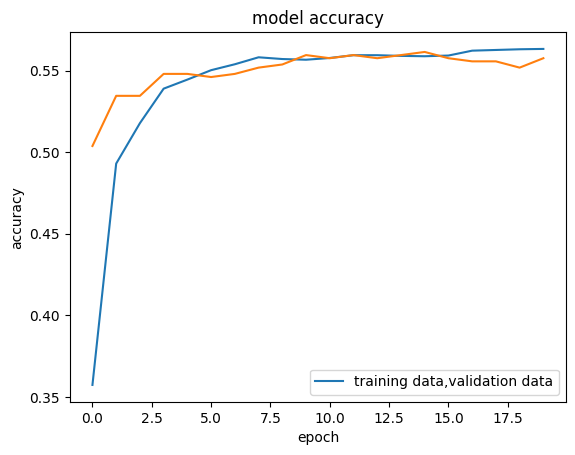

In [15]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['training data,validation data'],loc='lower right')

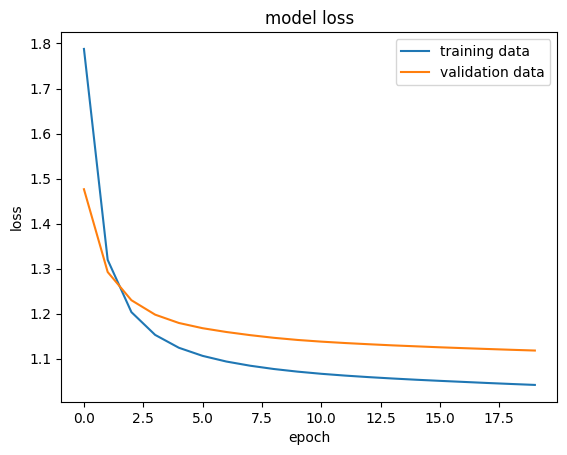

In [16]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['training data','validation data'],loc='upper right')

In [17]:
loss, accuracy = model.evaluate(X_test,Y_test)
print(accuracy)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5362 - loss: 1.0005
0.5361538529396057


In [18]:
Y_pred = model.predict(X_test)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [19]:
Y_pred_max = [np.argmax(i) for i in Y_pred]
print(Y_pred_max)

[np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(6), np.int64(6), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(5), np.int64(6), np.int64(7), np.int64(5), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(6), np.int64(5), np.int64(6), np.int64(5), np.int64(5), np.int64(6), np.int64(7), np.int64(6), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(5), np.int64(6)

In [20]:
input_data = [[0,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.531215,11.2]]
input_data_num_arr = np.asarray(input_data)
input_data_num_arr_reshaped = input_data_num_arr.reshape(1,-1)
input_data_arr_scale = scaler.transform(input_data_num_arr_reshaped)
prediction = model.predict(input_data_arr_scale)
print(prediction)
prediction_max = np.argmax(prediction)
print("Wine quality score is :",prediction_max)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[4.9449806e-04 4.6749255e-03 3.6435940e-03 3.1265569e-01 5.7513642e-01
  9.2019451e-01 9.2065561e-01 4.7470543e-01 1.5495393e-01 8.9459084e-03]]
Wine quality score is : 6


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
